#Comprehensive Deepfake Detection using Vision Transformer (ViT) and Gated Recurrent Unit (GRU) with Imbalance Handling
Overview:

Goal: To develop a robust deep learning model for detecting deepfake videos.

Model: A hybrid architecture combining a Vision Transformer (ViT) for spatial feature extraction from video frames and a Gated Recurrent Unit (GRU) for capturing temporal dependencies across frame sequences.

Key Techniques:


*   Transfer learning using a pre-trained ViT.
*   Sequential modeling with GRU.

*   Strategies to handle class imbalance in the dataset (e.g., weighted loss, weighted sampling).
*   Comprehensive evaluation metrics including ROC-AUC, Precision-Recall AUC, F1-score, and confusion matrix.


Dataset Description:
The dataset consists of pre-extracted frames from videos.
It contains approximately 4000 fake videos and 1361 real videos.
Each video originally had 27-32 frames; the data loader will sample a fixed number of frames.



#1. Environment Setup - Package Installation


In [ ]:
!pip install torch torchvision torchaudio timm numpy matplotlib seaborn scikit-learn pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjit

#2. Imports and Initial Configuration

In [ ]:
# Standard Python Libraries
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image # For loading images in the dataset class

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from torchvision.transforms import (
    RandomResizedCrop, RandomHorizontalFlip, ColorJitter,
    RandomRotation, RandomErasing, ToTensor, Normalize, Resize
)

# Timm (PyTorch Image Models)
from timm import create_model

# Scikit-learn Metrics
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score
)

# PyTorch AMP (Automatic Mixed Precision)
from torch.amp import autocast, GradScaler

#4: Reproducibility and Device Configuration

In [ ]:
def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
print(f"Using device: {device}")

# Initialize GradScaler for mixed-precision training
scaler = GradScaler(enabled=torch.cuda.is_available())

CUDA Available: True
Number of GPUs: 1
GPU 0: NVIDIA A100-SXM4-40GB
Using device: cuda


#5: Hyperparameters and Configuration Constants

In [ ]:
# Data parameters
DATASET_ROOT = "/content/drive/MyDrive/new_dataset/ND" # User needs to upload their 'ND' dataset here
NUM_FRAMES = 15  # Number of frames to sample per video
IMG_DIM = 224    # Image dimension for ViT input

# Model parameters
VIT_MODEL_NAME = 'vit_base_patch16_224_in21k' # A common ViT model
GRU_HIDDEN_DIM = 512
GRU_LAYERS = 2
BIDIRECTIONAL_GRU = True
DROPOUT_RATE = 0.5
NUM_CLASSES = 2 # real, fake

# Training parameters
BATCH_SIZE = 32 # Adjust based on GPU memory; A100 might handle 32 or more. Start with 16.
NUM_EPOCHS = 25
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 7 # For early stopping

# Class imbalance handling
# Note: It's often better to choose one primary method for oversampling/weighting.
# The setup allows exploring combinations, but careful tuning is needed.
APPLY_WEIGHTED_LOSS = True
APPLY_OVERSAMPLING_TRAIN_DATASET = False # If True, CustomImageFolder will manually oversample.
# OVERSAMPLE_MINORITY_RATIO_TRAIN: If APPLY_OVERSAMPLING_TRAIN_DATASET is True,
# this factor determines how much to increase the minority class.
# For example, if majority has 1000 samples and minority has 200:
# Ratio 1.0 aims for minority count ~1000 (oversample_factor ~4).
# Ratio 0.5 aims for minority count ~500 (oversample_factor ~1.5, so duplicates once).
# The provided formula is `oversample_factor = int((len(majority_samples) * oversample_minority_ratio) / len(minority_samples)) - 1`
# This means if ratio is 1.0, it tries to make minority equal to majority.
OVERSAMPLE_MINORITY_RATIO_TRAIN = 1.0

APPLY_WEIGHTED_RANDOM_SAMPLER_TRAIN = True # If True, DataLoader uses WeightedRandomSampler.

# Paths
CHECKPOINT_PATH = "vit_gru_deepfake_best.pt"
RESULTS_DIR = "vit_gru_results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Dataset root: {DATASET_ROOT}")
print(f"Number of frames per video: {NUM_FRAMES}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Apply Weighted Loss: {APPLY_WEIGHTED_LOSS}")
print(f"Apply Manual Oversampling (Train): {APPLY_OVERSAMPLING_TRAIN_DATASET}")
if APPLY_OVERSAMPLING_TRAIN_DATASET:
    print(f"Oversample Minority Ratio (Train): {OVERSAMPLE_MINORITY_RATIO_TRAIN}")
print(f"Apply Weighted Random Sampler (Train): {APPLY_WEIGHTED_RANDOM_SAMPLER_TRAIN}")

# Reminder for the user if using Colab
if DATASET_ROOT == "/content/ND":
    print("\n Reminder: Please ensure your 'ND' dataset is uploaded to /content/ND in your Colab environment.")
    print("It should be structured as: /content/ND/{train|val|test}/{real|fake}/{video_id}/{frame_images}")

Dataset root: /content/drive/MyDrive/new_dataset/ND
Number of frames per video: 15
Batch Size: 32
Apply Weighted Loss: True
Apply Manual Oversampling (Train): False
Apply Weighted Random Sampler (Train): True


#6: Custom Dataset Class (CustomImageFolder)

In [ ]:
from PIL import Image # Ensure PIL is imported

class CustomImageFolder(Dataset):
    def __init__(self, root, transform=None, num_frames=15, is_train_set=False, oversample_minority_ratio=1.0):
        self.root = Path(root)
        self.transform = transform
        self.num_frames = num_frames
        self.is_train_set = is_train_set # Flag to indicate if this is the training set
        self.oversample_minority_ratio = oversample_minority_ratio # Parameter for oversampling

        self.class_to_idx = {"real": 0, "fake": 1}
        self.idx_to_class = {v: k for k, v in self.class_to_idx.items()}
        self.samples = []
        real_samples = []
        fake_samples = []

        print(f"Loading dataset from: {self.root}")

        for class_name in self.class_to_idx.keys():
            class_idx = self.class_to_idx[class_name]
            class_dir = self.root / class_name
            if not class_dir.is_dir():
                print(f"Warning: Class directory {class_dir} not found.")
                continue

            for video_folder in sorted(class_dir.iterdir()): # Iterate through video folders
                if video_folder.is_dir():
                    frame_paths_jpg = sorted(list(video_folder.glob("*.jpg")))
                    frame_paths_png = sorted(list(video_folder.glob("*.png")))
                    frame_paths = frame_paths_jpg + frame_paths_png # Combine and assume they are sorted by name

                    if len(frame_paths) == 0:
                        # print(f"Warning: No frames found in {video_folder}. Skipping.")
                        continue

                    if len(frame_paths) >= self.num_frames:
                        # Sample frames using linspace
                        indices = np.linspace(0, len(frame_paths) - 1, self.num_frames, dtype=int)
                        selected_frame_paths = [frame_paths[i] for i in indices]
                        if class_name == "real":
                            real_samples.append((selected_frame_paths, class_idx))
                        else:
                            fake_samples.append((selected_frame_paths, class_idx))
                    else:
                        print(f"Warning: Video {video_folder.name} in {class_name} has only {len(frame_paths)} frames, less than required {self.num_frames}. Skipping.")

        print(f"Initial counts for split '{self.root.name}': Real videos: {len(real_samples)}, Fake videos: {len(fake_samples)}")

        if self.is_train_set and APPLY_OVERSAMPLING_TRAIN_DATASET and len(real_samples) > 0 and len(fake_samples) > 0:
            print("Applying manual oversampling to training dataset...")
            if len(real_samples) < len(fake_samples):
                minority_samples = real_samples
                majority_samples = fake_samples
                print(f"Minority class: 'real' ({len(minority_samples)}), Majority class: 'fake' ({len(majority_samples)})")
            else:
                minority_samples = fake_samples
                majority_samples = real_samples
                print(f"Minority class: 'fake' ({len(minority_samples)}), Majority class: 'real' ({len(majority_samples)})")

            # Calculate how many times to duplicate each minority sample
            # Example: majority=1000, minority=200. Ratio=1.0 -> target_minority=1000.
            # Factor = (1000 * 1.0 / 200) - 1 = 5 - 1 = 4.  So, 1 original + 4 duplicates = 5 copies total.
            # Minority becomes 200 * 5 = 1000.
            desired_minority_count = len(majority_samples) * self.oversample_minority_ratio
            if len(minority_samples) < desired_minority_count:
                oversample_factor = int(desired_minority_count / len(minority_samples)) -1
            else:
                oversample_factor = 0 # No oversampling needed if minority already meets ratio criteria

            print(f"Calculated oversample_factor: {oversample_factor} (each minority sample will be present {oversample_factor + 1} times)")

            if oversample_factor > 0:
                oversampled_minority = minority_samples * oversample_factor # Creates N copies of the list
                self.samples = real_samples + fake_samples + oversampled_minority
                print(f"Minority samples duplicated {oversample_factor} times.")
            else:
                self.samples = real_samples + fake_samples
                print("No oversampling applied as factor is not positive or minority meets criteria.")

            random.shuffle(self.samples)
            # Recalculate counts after oversampling
            final_real_count = sum(1 for _, label in self.samples if label == self.class_to_idx["real"])
            final_fake_count = sum(1 for _, label in self.samples if label == self.class_to_idx["fake"])
            print(f"Counts after oversampling for '{self.root.name}': Real videos: {final_real_count}, Fake videos: {final_fake_count}")
        else:
            self.samples = real_samples + fake_samples
            if self.is_train_set and APPLY_OVERSAMPLING_TRAIN_DATASET:
                if not (len(real_samples) > 0 and len(fake_samples) > 0) :
                     print("Skipping manual oversampling: one or both classes have zero samples.")
                else:
                    print("Manual oversampling not applied as APPLY_OVERSAMPLING_TRAIN_DATASET is False or not a training set.")


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        frame_paths_list, label = self.samples[idx]
        frames = []
        for frame_path in frame_paths_list:
            try:
                image = Image.open(frame_path).convert("RGB")
                if self.transform:
                    image = self.transform(image)
                frames.append(image)
            except Exception as e:
                print(f"Error loading or transforming image {frame_path}: {e}")
                # Handle error, e.g., return a placeholder or skip. For simplicity, re-raise or return None.
                # For this example, let's make sure we always return a tensor of the correct type.
                # A robust solution would involve more sophisticated error handling or data cleaning.
                # If an image fails, we might need to skip this sample or return a black image.
                # For now, if one frame fails, the stack operation will likely fail.
                # Let's create a dummy tensor to allow training to proceed, but this should be logged.
                if len(frames) < self.num_frames: # if error happened before all frames loaded
                    dummy_frame = torch.zeros((3, IMG_DIM, IMG_DIM)) # C, H, W
                    while len(frames) < self.num_frames:
                        frames.append(dummy_frame)
                    print(f"Warning: Replaced failing frame sequence at index {idx} with dummies.")
                break # Stop processing frames for this sample if one fails

        if len(frames) != self.num_frames:
             # This case should ideally not be hit if skipping logic in __init__ is robust
             # or if dummy frames are added correctly above.
            print(f"Warning: Sample at index {idx} does not have {self.num_frames} frames after loading. Has {len(frames)}. Padding with zeros.")
            dummy_frame = torch.zeros((3, IMG_DIM, IMG_DIM)) # C, H, W
            while len(frames) < self.num_frames:
                frames.append(dummy_frame)

        frames_tensor = torch.stack(frames) # Shape: (num_frames, C, H, W)
        return frames_tensor, torch.tensor(label, dtype=torch.long)

#7: Data Augmentation and Transforms

In [ ]:
train_transform = transforms.Compose([
    Resize((IMG_DIM, IMG_DIM)),
    RandomHorizontalFlip(p=0.5),
    RandomRotation(degrees=15),
    ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0, inplace=False) # Apply after ToTensor
])

val_test_transform = transforms.Compose([
    Resize((IMG_DIM, IMG_DIM)),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("Data transforms defined.")
# Example of how RandomErasing is applied after ToTensor and Normalize
# For RandomErasing, if 'value' is a single number, it's applied to all channels.
# If you want to erase with the mean of the normalized image (approx 0), 'value=0' is fine.
# Or, value can be a tuple (mean_R, mean_G, mean_B) if you want specific values per channel.

Data transforms defined.


#8: Dataset and DataLoader Instantiation

In [ ]:
# Instantiate datasets
train_dataset = CustomImageFolder(
    root=Path(DATASET_ROOT) / "train",
    transform=train_transform,
    num_frames=NUM_FRAMES,
    is_train_set=True, # Critical for enabling oversampling logic
    oversample_minority_ratio=OVERSAMPLE_MINORITY_RATIO_TRAIN if APPLY_OVERSAMPLING_TRAIN_DATASET else 1.0
)

val_dataset = CustomImageFolder(
    root=Path(DATASET_ROOT) / "val",
    transform=val_test_transform,
    num_frames=NUM_FRAMES
)

test_dataset = CustomImageFolder(
    root=Path(DATASET_ROOT) / "test",
    transform=val_test_transform,
    num_frames=NUM_FRAMES
)

print(f"\nDataset sizes: Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

# --- Weighted Cross-Entropy Loss ---
if APPLY_WEIGHTED_LOSS:
    # Calculate class counts from train_dataset.samples (after potential CustomImageFolder oversampling)
    # Ensure train_dataset is not empty
    if len(train_dataset) > 0:
        train_labels_for_loss_weights = [s[1] for s in train_dataset.samples]
        count_real_train_for_loss = sum(1 for label in train_labels_for_loss_weights if label == train_dataset.class_to_idx["real"])
        count_fake_train_for_loss = sum(1 for label in train_labels_for_loss_weights if label == train_dataset.class_to_idx["fake"])
        total_train_samples_for_loss = len(train_labels_for_loss_weights)

        if count_real_train_for_loss > 0 and count_fake_train_for_loss > 0:
            # Weight for class c = total_samples / (num_classes * count_c)
            weight_real = total_train_samples_for_loss / (NUM_CLASSES * count_real_train_for_loss)
            weight_fake = total_train_samples_for_loss / (NUM_CLASSES * count_fake_train_for_loss)
            weights_for_loss = torch.tensor([weight_real, weight_fake], dtype=torch.float).to(device)
            criterion = nn.CrossEntropyLoss(weight=weights_for_loss)
            print(f"Applying weighted CrossEntropyLoss. Weights: Real={weights_for_loss[0]:.2f}, Fake={weights_for_loss[1]:.2f}")
        else:
            print("Warning: One or more classes have zero samples in train_dataset for loss weight calculation. Using unweighted loss.")
            criterion = nn.CrossEntropyLoss()
            APPLY_WEIGHTED_LOSS = False # Disable if counts are zero
    else:
        print("Warning: Train dataset is empty. Using unweighted loss.")
        criterion = nn.CrossEntropyLoss()
        APPLY_WEIGHTED_LOSS = False # Disable if dataset is empty
else:
    criterion = nn.CrossEntropyLoss()
    print("Using standard (unweighted) CrossEntropyLoss.")


# --- WeightedRandomSampler for Training DataLoader ---
train_sampler = None
# Ensure train_dataset is not empty before trying to create a sampler
if APPLY_WEIGHTED_RANDOM_SAMPLER_TRAIN and len(train_dataset) > 0 :
    print("Configuring WeightedRandomSampler for training data...")
    # Get labels from train_dataset.samples (these are after CustomImageFolder oversampling, if any)
    train_labels_for_sampler = [s[1] for s in train_dataset.samples]

    class_counts_for_sampler = [0] * NUM_CLASSES
    for label in train_labels_for_sampler:
        class_counts_for_sampler[label] += 1

    if all(c > 0 for c in class_counts_for_sampler): # Ensure no class count is zero
        # Weight for each sample = 1.0 / count_of_its_class
        sample_weights = [1.0 / class_counts_for_sampler[label] for label in train_labels_for_sampler]
        train_sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
        print(f"WeightedRandomSampler configured. Class counts for sampler base: {class_counts_for_sampler}")
    else:
        print("Warning: Not applying WeightedRandomSampler because one or more classes have zero samples in train_dataset.")
        APPLY_WEIGHTED_RANDOM_SAMPLER_TRAIN = False # Disable if counts are zero
elif len(train_dataset) == 0 and APPLY_WEIGHTED_RANDOM_SAMPLER_TRAIN:
    print("Warning: Train dataset is empty. Cannot configure WeightedRandomSampler.")
    APPLY_WEIGHTED_RANDOM_SAMPLER_TRAIN = False # Disable if dataset is empty


# --- DataLoaders ---
# Ensure datasets are not empty before creating DataLoaders to avoid errors
if len(train_dataset) > 0:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=train_sampler if APPLY_WEIGHTED_RANDOM_SAMPLER_TRAIN else None,
        shuffle=False if (APPLY_WEIGHTED_RANDOM_SAMPLER_TRAIN and train_sampler) else True, # Shuffle if no sampler
        num_workers=2, # os.cpu_count() can be too high for Colab, stick to 2-4
        pin_memory=True
    )
else:
    train_loader = None # Or handle as an error
    print("Error: Training dataset is empty. Train loader not created.")


if len(val_dataset) > 0:
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
else:
    val_loader = None
    print("Warning: Validation dataset is empty. Validation loader not created.")


if len(test_dataset) > 0:
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
else:
    test_loader = None
    print("Warning: Test dataset is empty. Test loader not created.")

# Print a sample batch shape from train_loader if it exists
if train_loader:
    try:
        sample_batch, sample_labels = next(iter(train_loader))
        print(f"\nSample batch shape from train_loader: {sample_batch.shape}") # (BATCH_SIZE, NUM_FRAMES, C, H, W)
        print(f"Sample labels shape from train_loader: {sample_labels.shape}") # (BATCH_SIZE)
    except StopIteration:
        print("Could not retrieve a sample batch from train_loader, it might be empty or batch size > dataset size.")
    except Exception as e:
        print(f"Error retrieving sample batch: {e}")
else:
    print("Train loader not available to print sample batch shape.")

Loading dataset from: /content/drive/MyDrive/new_dataset/ND/train
Initial counts for split 'train': Real videos: 947, Fake videos: 2674
Loading dataset from: /content/drive/MyDrive/new_dataset/ND/val
Initial counts for split 'val': Real videos: 271, Fake videos: 798
Loading dataset from: /content/drive/MyDrive/new_dataset/ND/test
Initial counts for split 'test': Real videos: 137, Fake videos: 399

Dataset sizes: Train: 3621, Val: 1069, Test: 536
Applying weighted CrossEntropyLoss. Weights: Real=1.91, Fake=0.68
Configuring WeightedRandomSampler for training data...
WeightedRandomSampler configured. Class counts for sampler base: [947, 2674]

Sample batch shape from train_loader: torch.Size([32, 15, 3, 224, 224])
Sample labels shape from train_loader: torch.Size([32])


#9: ViT + GRU Model Definition (FaceClassifierViTGRU)

In [ ]:
class FaceClassifierViTGRU(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, vit_model_name=VIT_MODEL_NAME,
                 gru_hidden_dim=GRU_HIDDEN_DIM, gru_layers=GRU_LAYERS,
                 bidirectional_gru=BIDIRECTIONAL_GRU, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.num_classes = num_classes
        self.vit_model_name = vit_model_name
        self.gru_hidden_dim = gru_hidden_dim
        self.gru_layers = gru_layers
        self.bidirectional_gru = bidirectional_gru
        self.dropout_rate = dropout_rate

        # Load pre-trained ViT, remove its classification head
        self.vit = create_model(vit_model_name, pretrained=True, num_classes=0) # Outputs features
        self.vit_feature_dim = self.vit.embed_dim # For 'vit_base_patch16_224_in21k' this is 768

        # GRU layer
        self.gru = nn.GRU(
            input_size=self.vit_feature_dim,
            hidden_size=gru_hidden_dim,
            num_layers=gru_layers,
            batch_first=True, # Input and output tensors are (batch, seq, feature)
            bidirectional=bidirectional_gru,
            dropout=dropout_rate if gru_layers > 1 else 0 # Add dropout between GRU layers if multiple
        )

        # Calculate GRU output dimension
        gru_output_dim = gru_hidden_dim * (2 if bidirectional_gru else 1)

        # Classification head
        self.fc_head = nn.Sequential(
            nn.LayerNorm(gru_output_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(gru_output_dim, num_classes)
        )

    def forward(self, x):
        # x shape: (batch_size, seq_length/num_frames, C, H, W)
        batch_size, seq_length, C, H, W = x.shape

        # Process each frame through ViT
        # Reshape to (batch_size * seq_length, C, H, W) to pass all frames at once
        x_reshaped = x.view(batch_size * seq_length, C, H, W)

        # Get frame features from ViT
        # Output shape: (batch_size * seq_length, vit_feature_dim)
        frame_features = self.vit(x_reshaped)

        # Reshape features for GRU: (batch_size, seq_length, vit_feature_dim)
        gru_input = frame_features.view(batch_size, seq_length, self.vit_feature_dim)

        # Pass sequence through GRU
        # self.gru.flatten_parameters() # Good practice for multi-GPU, call before GRU forward if issues arise
        # For nn.DataParallel, usually not strictly needed for GRU as much as for LSTM on PackedSequence
        # but can be harmless. Let's keep it for good measure or remove if it causes issues.
        # It's more critical if using PackedSequence with LSTMs/GRUs and DataParallel.
        # For standard tensor inputs, it's often fine.

        gru_out, hidden_states = self.gru(gru_input)
        # gru_out shape: (batch_size, seq_length, gru_hidden_dim * num_directions)
        # hidden_states shape: (num_layers * num_directions, batch_size, gru_hidden_dim)

        # Aggregate GRU outputs
        # We can use the output of the last time step from the last layer,
        # or average pooling, or an attention mechanism.
        if self.bidirectional_gru:
            # Option 1: Concatenate the last hidden state from forward and backward pass
            # hidden_states is (num_layers*num_directions, batch, hidden_size)
            # Forward last hidden: hidden_states[-2, :, :]
            # Backward last hidden: hidden_states[-1, :, :]
            # aggregated_features = torch.cat((hidden_states[-2, :, :], hidden_states[-1, :, :]), dim=1)

            # Option 2: Use the mean of all time steps' outputs from the last GRU layer
            # This is simpler and often works well.
            aggregated_features = gru_out.mean(dim=1) # (batch_size, gru_hidden_dim * num_directions)
        else:
            # For unidirectional GRU, take the last time step's output from the last layer
            aggregated_features = gru_out[:, -1, :] # (batch_size, gru_hidden_dim)
            # Or equivalently, the last hidden state of the last layer:
            # aggregated_features = hidden_states[-1, :, :]

        # Pass through classification head
        output_logits = self.fc_head(aggregated_features) # (batch_size, num_classes)

        return output_logits

#10: Model Initialization, Optimizer, Scheduler, Early Stopping

In [ ]:
# Define EarlyStoppingWithCheckpoint class
class EarlyStoppingWithCheckpoint:
    """Early stops the training if validation loss doesn't improve after a given patience."""
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt', trace_func=print):
        """
        Args:
            patience (int): How long to wait after last time validation loss improved.
                            Default: 7
            verbose (bool): If True, prints a message for each validation loss improvement.
                            Default: False
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
                            Default: 0
            path (str): Path for the checkpoint to be saved to.
                            Default: 'checkpoint.pt'
            trace_func (function): trace print function.
                            Default: print
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path
        self.trace_func = trace_func

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decrease.'''
        if self.verbose:
            self.trace_func(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model to {self.path} ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

# --- Model Initialization ---
model = FaceClassifierViTGRU(
    num_classes=NUM_CLASSES,
    vit_model_name=VIT_MODEL_NAME,
    gru_hidden_dim=GRU_HIDDEN_DIM,
    gru_layers=GRU_LAYERS,
    bidirectional_gru=BIDIRECTIONAL_GRU,
    dropout_rate=DROPOUT_RATE
).to(device)

if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs via nn.DataParallel.")
    model = nn.DataParallel(model)

# Print model summary (number of parameters)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel initialized: {model.__class__.__name__}")
print(f"Total trainable parameters: {total_params:,}")

# --- Optimizer ---
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
print(f"Optimizer: AdamW (LR={LEARNING_RATE}, Weight Decay={WEIGHT_DECAY})")

# --- Scheduler ---
# ReduceLROnPlateau patience should ideally be less than early stopping patience.
scheduler_patience = PATIENCE // 2 if PATIENCE > 2 else 1
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',      # Reduce LR when val_loss stops decreasing
    factor=0.1,      # Reduce LR by a factor of 0.1
    patience=scheduler_patience,
    verbose=True
)
print(f"Scheduler: ReduceLROnPlateau (Factor=0.1, Patience={scheduler_patience})")

# --- Early Stopping ---
early_stopping = EarlyStoppingWithCheckpoint(
    patience=PATIENCE,
    verbose=True,
    path=CHECKPOINT_PATH,
    trace_func=print
)
print(f"Early Stopping: Patience={PATIENCE}, Checkpoint path: {CHECKPOINT_PATH}")


Model initialized: FaceClassifierViTGRU
Total trainable parameters: 94,465,794
Optimizer: AdamW (LR=1e-05, Weight Decay=0.0001)
Scheduler: ReduceLROnPlateau (Factor=0.1, Patience=3)
Early Stopping: Patience=7, Checkpoint path: vit_gru_deepfake_best.pt


#11: Training and Evaluation Helper Functions

In [ ]:
class RunningAverage:
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

# calculate_accuracy can be done directly or using sklearn.accuracy_score
# For simplicity, we'll calculate within evaluate, but here's how it could be:
# def calculate_accuracy(outputs, targets):
#     _, predicted = torch.max(outputs.data, 1)
#     total = targets.size(0)
#     correct = (predicted == targets).sum().item()
#     return correct / total

def train_epoch(model, train_loader, criterion, optimizer, device, scaler, epoch_num, num_epochs):
    model.train()
    train_loss_avg = RunningAverage()
    train_acc_avg = RunningAverage()

    print_every_n_batches = max(1, len(train_loader) // 10) # Print progress ~10 times per epoch

    for i, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()

        # Mixed precision context
        with autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            outputs = model(inputs)
            loss = criterion(outputs, targets)

        if device.type == 'cuda':
            scaler.scale(loss).backward()
            # Optional: Gradient clipping if you experience exploding gradients
            # scaler.unscale_(optimizer) # Unscale gradients before clipping
            # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else: # CPU path
            loss.backward()
            optimizer.step()

        # Calculate accuracy
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probs, 1)
        accuracy = (preds == targets).float().mean().item()

        train_loss_avg.update(loss.item(), inputs.size(0))
        train_acc_avg.update(accuracy, inputs.size(0))

        if (i + 1) % print_every_n_batches == 0 or (i + 1) == len(train_loader):
            print(f"Epoch [{epoch_num+1}/{num_epochs}], Batch [{i+1}/{len(train_loader)}]: "
                  f"Train Loss: {train_loss_avg.avg:.4f}, Train Acc: {train_acc_avg.avg:.4f}")

    return train_loss_avg.avg, train_acc_avg.avg


def evaluate(model, data_loader, criterion, device):
    model.eval()
    eval_loss_avg = RunningAverage()
    eval_acc_avg = RunningAverage()

    all_labels_list = []
    all_preds_list = []
    all_scores_list = [] # Probabilities for the positive class (fake)

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            # No autocast needed for evaluation usually, unless model structure demands it or for speed on specific hardware.
            # Standard precision is fine for robust evaluation.
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            # Calculate probabilities and predictions
            scores = torch.softmax(outputs, dim=1)
            _, preds = torch.max(scores, 1)
            accuracy = (preds == targets).float().mean().item() # batch accuracy

            eval_loss_avg.update(loss.item(), inputs.size(0))
            eval_acc_avg.update(accuracy, inputs.size(0))

            all_labels_list.append(targets.cpu().numpy())
            all_preds_list.append(preds.cpu().numpy())
            all_scores_list.append(scores[:, 1].cpu().numpy()) # Assuming class 1 is "fake"

    all_labels_np = np.concatenate(all_labels_list)
    all_preds_np = np.concatenate(all_preds_list)
    all_scores_np = np.concatenate(all_scores_list)

    return eval_loss_avg.avg, eval_acc_avg.avg, all_labels_np, all_preds_np, all_scores_np

print("Training and evaluation helper functions defined.")

Training and evaluation helper functions defined.


#12: Training Loop

In [ ]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Check if train_loader and val_loader exist
if train_loader is None or val_loader is None:
    print("Error: train_loader or val_loader is not initialized. Skipping training loop.")
    # You might want to raise an error or exit if this happens,
    # depending on how critical training is to subsequent cells.
    # For now, we'll just print and let later cells potentially fail if they depend on training.
else:
    print(f"\nStarting training for {NUM_EPOCHS} epochs on {device}...")
    start_time = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_start_time = time.time()
        print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")

        # Training step
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current Learning Rate: {current_lr:.2e}")

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device, scaler, epoch, NUM_EPOCHS)
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validation step
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        val_accuracies.append(val_acc)

        epoch_duration = time.time() - epoch_start_time

        print(f"Epoch {epoch+1} Summary: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
              f"Duration: {epoch_duration:.2f}s")

        # Adjust learning rate
        scheduler.step(val_loss)

        # Early stopping
        early_stopping(val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered.")
            break

    training_time = time.time() - start_time
    print(f"\n--- Training Finished ---")
    print(f"Total Training Time: {training_time//60:.0f}m {training_time%60:.0f}s")

    # Load the best model if early stopping occurred and saved a checkpoint
    if early_stopping.early_stop or (os.path.exists(CHECKPOINT_PATH) and NUM_EPOCHS > 0) :
        print(f"Loading best model weights from {CHECKPOINT_PATH} for final evaluation.")
        # Need to handle DataParallel wrapper if it was used
        if isinstance(model, nn.DataParallel):
            model.module.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
        else:
            model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    elif NUM_EPOCHS == 0 :
        print("No training epochs were run. Model is in initial state.")
    else:
        print("Training completed all epochs or no checkpoint saved. Using current model weights.")

# Ensure RESULTS_DIR exists for saving plots
os.makedirs(RESULTS_DIR, exist_ok=True)


Starting training for 25 epochs on cuda...

--- Epoch 1/25 ---
Current Learning Rate: 1.00e-05
Epoch [1/25], Batch [11/114]: Train Loss: 0.6643, Train Acc: 0.5085
Epoch [1/25], Batch [22/114]: Train Loss: 0.6375, Train Acc: 0.5256
Epoch [1/25], Batch [33/114]: Train Loss: 0.6234, Train Acc: 0.5256
Epoch [1/25], Batch [44/114]: Train Loss: 0.6192, Train Acc: 0.5156
Epoch [1/25], Batch [55/114]: Train Loss: 0.6101, Train Acc: 0.5148
Epoch [1/25], Batch [66/114]: Train Loss: 0.6033, Train Acc: 0.5142
Epoch [1/25], Batch [77/114]: Train Loss: 0.5951, Train Acc: 0.5191
Epoch [1/25], Batch [88/114]: Train Loss: 0.5876, Train Acc: 0.5256
Epoch [1/25], Batch [99/114]: Train Loss: 0.5832, Train Acc: 0.5297
Epoch [1/25], Batch [110/114]: Train Loss: 0.5736, Train Acc: 0.5378
Epoch [1/25], Batch [114/114]: Train Loss: 0.5691, Train Acc: 0.5438
Epoch 1 Summary: Train Loss: 0.5691, Train Acc: 0.5438 | Val Loss: 1.5612, Val Acc: 0.2535 | Duration: 5799.97s
Validation loss decreased (inf --> 1.56118

#13: Plotting Training History and Metrics Functions

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score

def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies, save_dir):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'bo-', label='Training Loss')
    plt.plot(epochs, val_losses, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accuracies, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_accuracies, 'ro-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    save_path = Path(save_dir) / "training_history.png"
    plt.savefig(save_path)
    print(f"Training history plot saved to {save_path}")
    plt.show()

def plot_confusion_matrix_and_report(y_true, y_pred_classes, y_pred_scores, class_names=["Real", "Fake"], save_dir="."):
    Path(save_dir).mkdir(parents=True, exist_ok=True)

    # --- Classification Report ---
    report_str = classification_report(y_true, y_pred_classes, target_names=class_names, digits=4)
    print("\nClassification Report:")
    print(report_str)
    # Save report to text file
    report_txt_path = Path(save_dir) / "classification_report.txt"
    with open(report_txt_path, 'w') as f:
        f.write(report_str)
    print(f"Classification report saved to {report_txt_path}")

    # Attempt to save report as an image
    try:
        fig, ax = plt.subplots(figsize=(8, max(4, len(class_names) * 1.5))) # Adjust size based on num classes
        ax.text(0.01, 0.99, report_str, va='top', ha='left', family='monospace', fontsize=10)
        ax.axis('off') # Hide axes
        plt.title("Classification Report", fontsize=14, y=1.02)
        report_img_path = Path(save_dir) / "classification_report_image.png"
        plt.savefig(report_img_path, bbox_inches='tight', dpi=300)
        print(f"Classification report image saved to {report_img_path}")
        plt.close(fig) # Close the figure to free memory
    except Exception as e:
        print(f"Could not save classification report as image: {e}")


    # --- Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 12})
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    cm_path = Path(save_dir) / "confusion_matrix.png"
    plt.savefig(cm_path)
    print(f"Confusion matrix plot saved to {cm_path}")
    plt.show()


    # --- ROC Curve and AUC ---
    # Assuming class 1 ("Fake") is the positive class for ROC/PR curves
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_pred_scores) # y_pred_scores are probs for positive class
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    roc_path = Path(save_dir) / "roc_curve.png"
    plt.savefig(roc_path)
    print(f"ROC curve plot saved to {roc_path}")
    plt.show()


    # --- Precision-Recall Curve and Average Precision ---
    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_pred_scores)
    avg_precision = average_precision_score(y_true, y_pred_scores)

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AP = {avg_precision:.4f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="best")
    plt.grid(True)
    pr_path = Path(save_dir) / "precision_recall_curve.png"
    plt.savefig(pr_path)
    print(f"Precision-Recall curve plot saved to {pr_path}")
    plt.show()

print("Plotting functions defined.")

Plotting functions defined.


#14: Final Evaluation on Test Set and Reporting


--- Final Evaluation on Test Set ---
Loading best model weights from: vit_gru_deepfake_best.pt
Best model weights loaded successfully.

Test Set Performance:
Test Loss: 0.2224
Test Accuracy: 0.9403

Plotting training history...
Training history plot saved to vit_gru_results/training_history.png


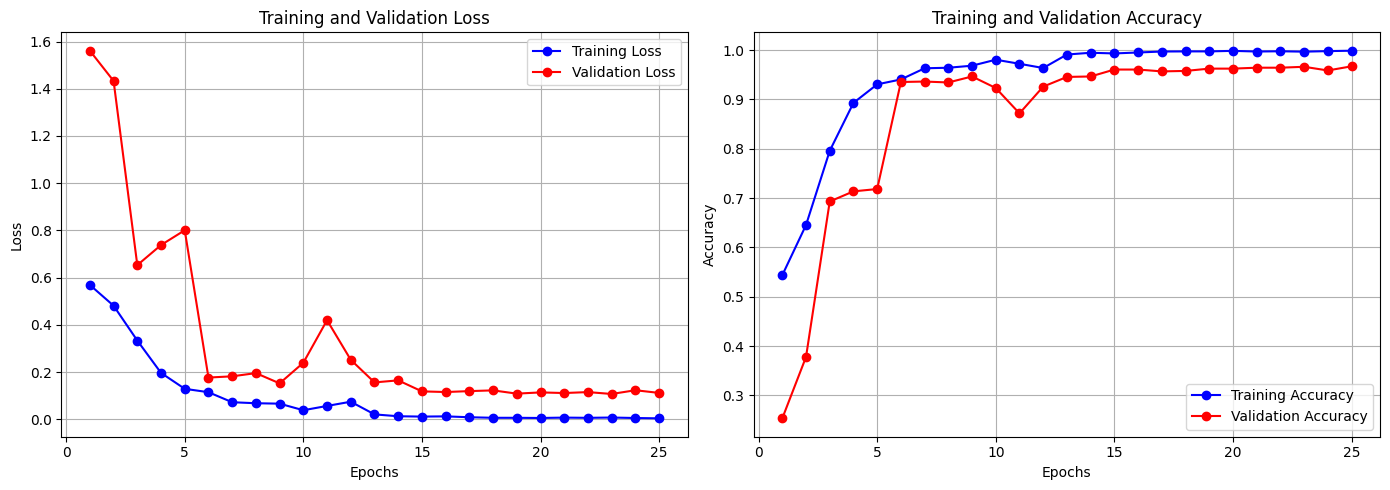


Generating detailed metrics plots for the test set...

Classification Report:
              precision    recall  f1-score   support

        real     0.8777    0.8905    0.8841       137
        fake     0.9622    0.9574    0.9598       399

    accuracy                         0.9403       536
   macro avg     0.9200    0.9240    0.9219       536
weighted avg     0.9406    0.9403    0.9404       536

Classification report saved to vit_gru_results/classification_report.txt
Classification report image saved to vit_gru_results/classification_report_image.png
Confusion matrix plot saved to vit_gru_results/confusion_matrix.png


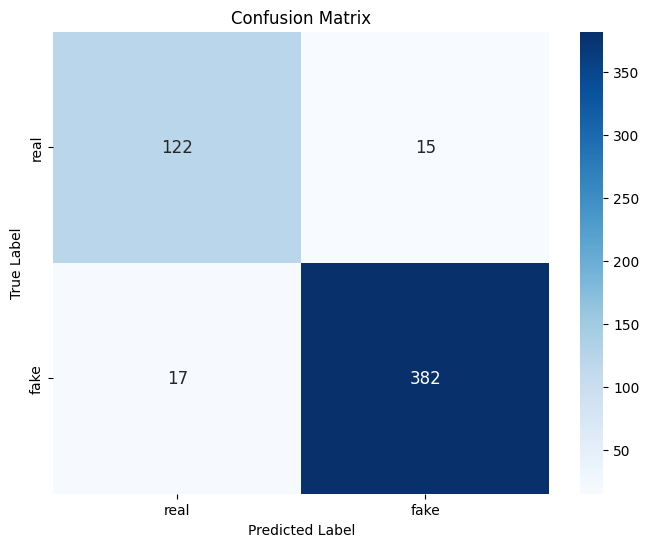

ROC curve plot saved to vit_gru_results/roc_curve.png


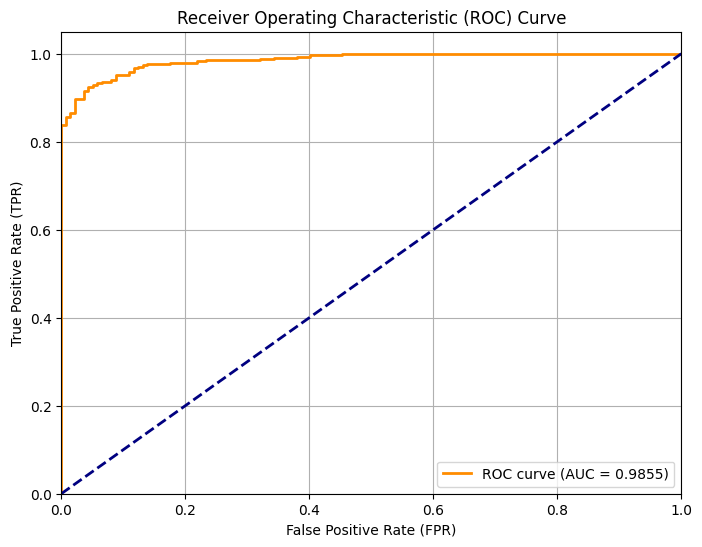

Precision-Recall curve plot saved to vit_gru_results/precision_recall_curve.png


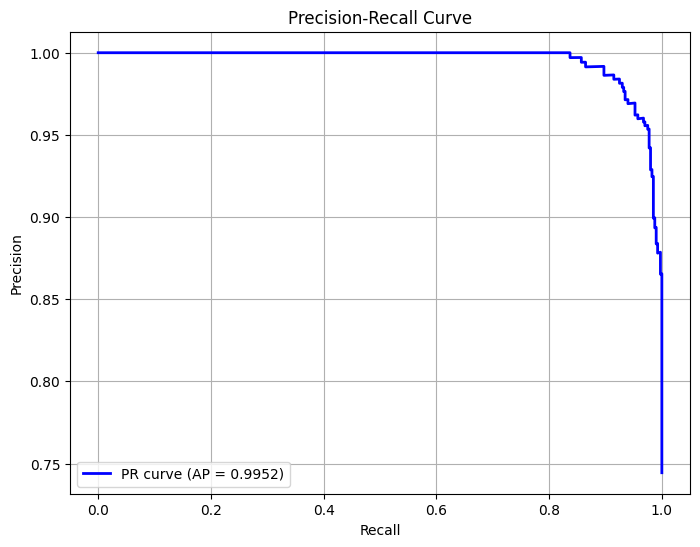


--- Summary of Test Set Metrics ---
                    Metric  Score
          Overall Accuracy 0.9403
          Precision (real) 0.8777
             Recall (real) 0.8905
           F1-score (real) 0.8841
          Precision (fake) 0.9622
             Recall (fake) 0.9574
           F1-score (fake) 0.9598
    Macro Average F1-score 0.9219
 Weighted Average F1-score 0.9404
                   AUC-ROC 0.9855
Average Precision (AUC-PR) 0.9952

Test metrics summary saved to vit_gru_results/test_metrics_summary.csv


In [ ]:
# Ensure RESULTS_DIR exists
os.makedirs(RESULTS_DIR, exist_ok=True)

# Check if the model and test_loader are available
if 'model' not in locals() or model is None:
    print("Model not defined or initialized. Cannot proceed with evaluation.")
elif test_loader is None:
    print("Test loader not available (e.g., test dataset might be empty or not loaded). Skipping test set evaluation.")
else:
    print("\n--- Final Evaluation on Test Set ---")
    # Load the best model weights
    if os.path.exists(CHECKPOINT_PATH):
        print(f"Loading best model weights from: {CHECKPOINT_PATH}")
        try:
            # Handle DataParallel wrapper if it was used during saving
            state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
            if isinstance(model, nn.DataParallel):
                # If the saved model was DataParallel, it prepends 'module.' to keys
                # If current model is also DataParallel, direct load is fine.
                # If current model is not, but saved was, keys need stripping.
                # A common robust way is to try loading directly, if fails, try stripping 'module.'
                try:
                    model.load_state_dict(state_dict)
                except RuntimeError: # Often due to 'module.' prefix mismatch
                    print("Direct load_state_dict failed. Attempting to load by adjusting for 'module.' prefix if needed.")
                    from collections import OrderedDict
                    new_state_dict = OrderedDict()
                    is_saved_parallel = any(key.startswith('module.') for key in state_dict.keys())

                    if is_saved_parallel and not isinstance(model, nn.DataParallel): # Saved parallel, current not
                        for k, v in state_dict.items():
                            name = k[7:] if k.startswith('module.') else k # remove `module.`
                            new_state_dict[name] = v
                        model.load_state_dict(new_state_dict)
                    elif not is_saved_parallel and isinstance(model, nn.DataParallel): # Saved not parallel, current is
                         for k, v in state_dict.items():
                            name = 'module.' + k # add `module.`
                            new_state_dict[name] = v
                         model.load_state_dict(new_state_dict)
                    else: # Both same (parallel or not parallel) or other mismatch
                        model.load_state_dict(state_dict) # Will likely re-raise the error if structure is truly different
            else: # Model is not nn.DataParallel
                 # If state_dict has 'module.' prefix (saved from DataParallel), strip it
                if any(key.startswith('module.') for key in state_dict.keys()):
                    from collections import OrderedDict
                    new_state_dict = OrderedDict()
                    for k, v in state_dict.items():
                        name = k[7:] if k.startswith('module.') else k
                        new_state_dict[name] = v
                    model.load_state_dict(new_state_dict)
                else:
                    model.load_state_dict(state_dict)

            print("Best model weights loaded successfully.")
        except Exception as e:
            print(f"Error loading model weights: {e}. Evaluating with current model weights (if any).")
    else:
        print(f"Checkpoint file {CHECKPOINT_PATH} not found. Evaluating with current model weights (if any).")

    # Evaluate on the test set
    test_loss, test_acc, test_true_labels, test_pred_classes, test_pred_scores = evaluate(
        model, test_loader, criterion, device
    )
    print(f"\nTest Set Performance:")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    # Plot training history (if data is available)
    if train_losses and val_losses and train_accuracies and val_accuracies:
        print("\nPlotting training history...")
        plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies, save_dir=RESULTS_DIR)
    else:
        print("\nNo training history data to plot (e.g., training was skipped or NUM_EPOCHS=0).")

    # Plot confusion matrix, classification report, ROC, PR curves for the test set
    print("\nGenerating detailed metrics plots for the test set...")
    class_names = [test_dataset.idx_to_class[i] for i in range(NUM_CLASSES)] # ["Real", "Fake"]
    plot_confusion_matrix_and_report(
        test_true_labels,
        test_pred_classes,
        test_pred_scores, # Probabilities for the positive class (Fake)
        class_names=class_names,
        save_dir=RESULTS_DIR
    )

    # --- Create a Pandas DataFrame for Key Metrics ---
    print("\n--- Summary of Test Set Metrics ---")
    # Assuming class 0 is "Real" and class 1 is "Fake"
    # test_dataset.class_to_idx should be {"real": 0, "fake": 1}
    idx_real = test_dataset.class_to_idx.get("real", 0)
    idx_fake = test_dataset.class_to_idx.get("fake", 1)


    precision_real = precision_score(test_true_labels, test_pred_classes, pos_label=idx_real, average='binary', zero_division=0)
    recall_real = recall_score(test_true_labels, test_pred_classes, pos_label=idx_real, average='binary', zero_division=0)
    f1_real = f1_score(test_true_labels, test_pred_classes, pos_label=idx_real, average='binary', zero_division=0)

    precision_fake = precision_score(test_true_labels, test_pred_classes, pos_label=idx_fake, average='binary', zero_division=0)
    recall_fake = recall_score(test_true_labels, test_pred_classes, pos_label=idx_fake, average='binary', zero_division=0)
    f1_fake = f1_score(test_true_labels, test_pred_classes, pos_label=idx_fake, average='binary', zero_division=0)

    macro_f1 = f1_score(test_true_labels, test_pred_classes, average='macro', zero_division=0)
    weighted_f1 = f1_score(test_true_labels, test_pred_classes, average='weighted', zero_division=0)

    # Calculate AUC-ROC and Average Precision (AUC-PR)
    # y_pred_scores are probabilities of the positive class (Fake, class 1)
    roc_auc_val = auc(roc_curve(test_true_labels, test_pred_scores)[0], roc_curve(test_true_labels, test_pred_scores)[1])
    avg_precision_val = average_precision_score(test_true_labels, test_pred_scores)


    metrics_summary = pd.DataFrame({
        'Metric': [
            'Overall Accuracy',
            f'Precision ({class_names[idx_real]})', f'Recall ({class_names[idx_real]})', f'F1-score ({class_names[idx_real]})',
            f'Precision ({class_names[idx_fake]})', f'Recall ({class_names[idx_fake]})', f'F1-score ({class_names[idx_fake]})',
            'Macro Average F1-score',
            'Weighted Average F1-score',
            'AUC-ROC',
            'Average Precision (AUC-PR)'
        ],
        'Score': [
            accuracy_score(test_true_labels, test_pred_classes),
            precision_real, recall_real, f1_real,
            precision_fake, recall_fake, f1_fake,
            macro_f1,
            weighted_f1,
            roc_auc_val,
            avg_precision_val
        ]
    })
    metrics_summary['Score'] = metrics_summary['Score'].round(4)
    print(metrics_summary.to_string(index=False))

    # Save summary to CSV
    summary_csv_path = Path(RESULTS_DIR) / "test_metrics_summary.csv"
    metrics_summary.to_csv(summary_csv_path, index=False)
    print(f"\nTest metrics summary saved to {summary_csv_path}")

#15: Hyperparameter and Results Summary

In [ ]:
 # This cell is optional, for generating the markdown tables dynamically.
# Ensure this is run AFTER all hyperparameters are set and AFTER Cell 14 has produced 'metrics_summary'

# Hyperparameters Table
md_hyperparams = f"""
## Run Configuration Summary

| Hyperparameter                       | Value                                     |
| :----------------------------------- | :---------------------------------------- |
| **Data Parameters** |                                           |
| Dataset Root                         | `{DATASET_ROOT}`                        |
| Num Frames per Video (`NUM_FRAMES`)  | `{NUM_FRAMES}`                            |
| Image Dimension (`IMG_DIM`)          | `{IMG_DIM}x{IMG_DIM}`                     |
| **Model Parameters** |                                           |
| ViT Model Name (`VIT_MODEL_NAME`)    | `{VIT_MODEL_NAME}`                      |
| GRU Hidden Dim (`GRU_HIDDEN_DIM`)    | `{GRU_HIDDEN_DIM}`                        |
| GRU Layers (`GRU_LAYERS`)            | `{GRU_LAYERS}`                            |
| Bidirectional GRU (`BIDIRECTIONAL_GRU`)| `{BIDIRECTIONAL_GRU}`                     |
| Dropout Rate (`DROPOUT_RATE`)        | `{DROPOUT_RATE}`                          |
| Num Classes (`NUM_CLASSES`)          | `{NUM_CLASSES}`                           |
| **Training Parameters** |                                           |
| Batch Size (`BATCH_SIZE`)            | `{BATCH_SIZE}`                            |
| Max Epochs (`NUM_EPOCHS`)            | `{NUM_EPOCHS}`                            |
| Learning Rate (`LEARNING_RATE`)      | `{LEARNING_RATE}`                         |
| Weight Decay (`WEIGHT_DECAY`)        | `{WEIGHT_DECAY}`                          |
| Early Stopping Patience (`PATIENCE`) | `{PATIENCE}`                              |
| LR Scheduler Patience                | `{PATIENCE // 2 if PATIENCE > 2 else 1}`  |
| **Class Imbalance Handling** |                                           |
| Apply Weighted Loss                  | `{APPLY_WEIGHTED_LOSS}`                   |
| Apply Manual Oversampling (Train)    | `{APPLY_OVERSAMPLING_TRAIN_DATASET}`      |
| Oversample Minority Ratio (Train)    | `{OVERSAMPLE_MINORITY_RATIO_TRAIN if APPLY_OVERSAMPLING_TRAIN_DATASET else "N/A"}` |
| Apply Weighted Random Sampler (Train)| `{APPLY_WEIGHTED_RANDOM_SAMPLER_TRAIN}`   |
| **Paths** |                                           |
| Checkpoint Path                      | `{CHECKPOINT_PATH}`                     |
| Results Directory                    | `{RESULTS_DIR}`                         |
"""
print("--- Hyperparameter Markdown ---")
print(md_hyperparams)

# Results Table (assuming 'metrics_summary' DataFrame exists from Cell 14)
if 'metrics_summary' in locals() and isinstance(metrics_summary, pd.DataFrame):
    md_results = "## Test Set Performance Summary\n\n"
    md_results += metrics_summary.to_markdown(index=False)
    print("\n\n--- Test Set Performance Markdown ---")
    print(md_results)
else:
    print("\n\n'metrics_summary' DataFrame not found. Run Cell 14 to generate it.")

--- Hyperparameter Markdown ---

## Run Configuration Summary

| Hyperparameter                       | Value                                     |
| :----------------------------------- | :---------------------------------------- |
| **Data Parameters** |                                           |
| Dataset Root                         | `/content/drive/MyDrive/new_dataset/ND`                        |
| Num Frames per Video (`NUM_FRAMES`)  | `15`                            |
| Image Dimension (`IMG_DIM`)          | `224x224`                     |
| **Model Parameters** |                                           |
| ViT Model Name (`VIT_MODEL_NAME`)    | `vit_base_patch16_224_in21k`                      |
| GRU Hidden Dim (`GRU_HIDDEN_DIM`)    | `512`                        |
| GRU Layers (`GRU_LAYERS`)            | `2`                            |
| Bidirectional GRU (`BIDIRECTIONAL_GRU`)| `True`                     |
| Dropout Rate (`DROPOUT_RATE`)        | `0.5`                   

Loading model weights from: vit_gru_deepfake_best.pt
Model weights loaded successfully.

Upload image frames for deepfake detection:


Saving frame_0000_face_00 - Copy.jpg to frame_0000_face_00 - Copy (1).jpg
Saving frame_0000_face_00.jpg to frame_0000_face_00 (2).jpg
Saving frame_0001_face_00 - Copy.jpg to frame_0001_face_00 - Copy.jpg
Saving frame_0001_face_00.jpg to frame_0001_face_00 (1).jpg
Saving frame_0002_face_00.jpg to frame_0002_face_00 (1).jpg
Saving frame_0003_face_00.jpg to frame_0003_face_00 (1).jpg
Saving frame_0004_face_00.jpg to frame_0004_face_00 (1).jpg
Saving frame_0005_face_00.jpg to frame_0005_face_00 (2).jpg
Saving frame_0006_face_00.jpg to frame_0006_face_00 (2).jpg
Saving frame_0007_face_00.jpg to frame_0007_face_00 (1).jpg
Saving frame_0008_face_00.jpg to frame_0008_face_00 (2).jpg
Saving frame_0009_face_00.jpg to frame_0009_face_00 (1).jpg
Saving frame_0010_face_00.jpg to frame_0010_face_00 (2).jpg
Saving frame_0011_face_00.jpg to frame_0011_face_00 (2).jpg
Saving frame_0012_face_00.jpg to frame_0012_face_00 (2).jpg
Saving frame_0013_face_00.jpg to frame_0013_face_00 (2).jpg
Saving frame_001

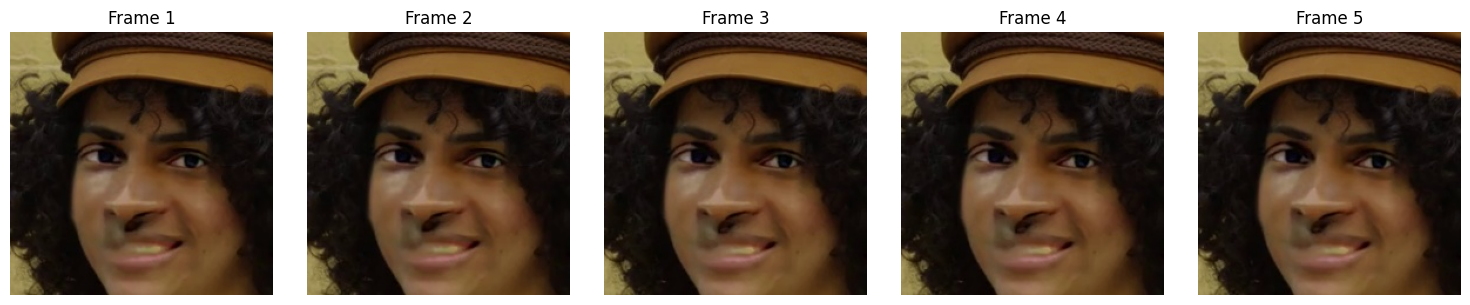

In [ ]:
import os
import numpy as np
import torch
from PIL import Image
from google.colab import files
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict # For loading model state dict

# --- Ensure necessary variables from previous cells are available ---
# These would have been defined in your notebook (e.g., Cell 5, Cell 7, Cell 10)
# Make sure these are consistent with your training setup.
# NUM_FRAMES, IMG_DIM, val_test_transform, device, CHECKPOINT_PATH, FaceClassifierViTGRU
# VIT_MODEL_NAME, GRU_HIDDEN_DIM, GRU_LAYERS, BIDIRECTIONAL_GRU, DROPOUT_RATE, NUM_CLASSES

# Define idx_to_class mapping (consistent with CustomImageFolder)
# Assuming class_to_idx = {"real": 0, "fake": 1}
idx_to_class = {0: "Real", 1: "Fake"}

def load_model_for_inference(model_class, checkpoint_path, device, *args, **kwargs):
    """Loads the model and its weights for inference."""
    infer_model = model_class(*args, **kwargs) # Instantiate with original parameters

    if not os.path.exists(checkpoint_path):
        print(f"Error: Checkpoint file not found at {checkpoint_path}. Cannot load model for inference.")
        return None

    print(f"Loading model weights from: {checkpoint_path}")
    try:
        state_dict = torch.load(checkpoint_path, map_location=device)
        # Handle potential 'module.' prefix if the model was saved using nn.DataParallel
        # and is now being loaded without it (or vice-versa).

        # Check if the current model instance is DataParallel
        is_current_model_parallel = isinstance(infer_model, nn.DataParallel)
        # Check if the saved state_dict has keys starting with 'module.'
        is_saved_state_parallel = any(key.startswith('module.') for key in state_dict.keys())

        if is_saved_state_parallel and not is_current_model_parallel:
            # Saved with DataParallel, loading without: strip 'module.'
            new_state_dict = OrderedDict()
            for k, v in state_dict.items():
                name = k[7:] if k.startswith('module.') else k
                new_state_dict[name] = v
            infer_model.load_state_dict(new_state_dict)
            print("Stripped 'module.' prefix from saved state_dict keys.")
        elif not is_saved_state_parallel and is_current_model_parallel:
            # Saved without DataParallel, loading with: add 'module.'
            # This case is less common for inference if you instantiate the base model
            # and then wrap it. If infer_model is already wrapped, this might not be needed.
            # For simplicity, we assume infer_model is the base model here.
            # If you intend to wrap infer_model in DataParallel AFTER loading,
            # then load into the base model first.
            print("Warning: Saved model is not DataParallel, but attempting to load into a DataParallel structure or vice-versa without explicit handling for adding 'module.' might be an issue. Ensure model structure matches.")
            infer_model.load_state_dict(state_dict) # Try direct load
        else:
            # Both are parallel or both are not, or direct load is fine
            infer_model.load_state_dict(state_dict)

        print("Model weights loaded successfully.")
    except Exception as e:
        print(f"Error loading model weights: {e}. Please ensure the model architecture matches the checkpoint.")
        return None

    infer_model = infer_model.to(device)
    infer_model.eval()
    return infer_model

def preprocess_uploaded_frames(uploaded_files_dict, num_target_frames, transform):
    """Loads, sorts, selects/pads, and transforms uploaded frames."""
    if not uploaded_files_dict:
        print("No files were uploaded.")
        return None

    uploaded_frame_paths = []
    temp_upload_dir = "temp_uploaded_images"
    os.makedirs(temp_upload_dir, exist_ok=True)

    for filename, file_content in uploaded_files_dict.items():
        file_path = os.path.join(temp_upload_dir, filename)
        with open(file_path, 'wb') as f:
            f.write(file_content)
        uploaded_frame_paths.append(Path(file_path))

    # Sort frames by name (assuming names imply order)
    uploaded_frame_paths.sort()

    print(f"Successfully saved {len(uploaded_frame_paths)} uploaded frames to {temp_upload_dir}.")
    print(f"Frame paths: {[str(p) for p in uploaded_frame_paths]}")


    selected_frames_pil = []
    actual_num_uploaded = len(uploaded_frame_paths)

    if actual_num_uploaded == 0:
        print("No frames processed after saving.")
        # Clean up temp directory
        for p in uploaded_frame_paths: os.remove(p)
        if os.path.exists(temp_upload_dir) and not os.listdir(temp_upload_dir): os.rmdir(temp_upload_dir)
        return None

    final_frame_paths_to_load = []
    if actual_num_uploaded >= num_target_frames:
        print(f"Selecting {num_target_frames} frames from {actual_num_uploaded} uploaded frames.")
        indices = np.linspace(0, actual_num_uploaded - 1, num_target_frames, dtype=int)
        final_frame_paths_to_load = [uploaded_frame_paths[i] for i in indices]
    else: # actual_num_uploaded < num_target_frames
        print(f"Warning: Uploaded {actual_num_uploaded} frames, which is less than the required {num_target_frames}.")
        print(f"Padding sequence by repeating the last frame.")
        final_frame_paths_to_load = list(uploaded_frame_paths) # Take all uploaded
        if actual_num_uploaded > 0:
            last_frame_path = uploaded_frame_paths[-1]
            while len(final_frame_paths_to_load) < num_target_frames:
                final_frame_paths_to_load.append(last_frame_path)
        else: # Should not happen if initial check for uploaded_files_dict is done
            print("Error: No frames to process for padding.")
            # Clean up temp directory
            for p in uploaded_frame_paths: os.remove(p)
            if os.path.exists(temp_upload_dir) and not os.listdir(temp_upload_dir): os.rmdir(temp_upload_dir)
            return None


    processed_frames_tensor_list = []
    loaded_pil_images = [] # For display

    for frame_path in final_frame_paths_to_load:
        try:
            img = Image.open(frame_path).convert("RGB")
            loaded_pil_images.append(img.copy()) # Save a copy for display before transform
            img_tensor = transform(img)
            processed_frames_tensor_list.append(img_tensor)
        except Exception as e:
            print(f"Error processing frame {frame_path}: {e}")
            # Clean up temp directory
            for p_rem in uploaded_frame_paths:
                if os.path.exists(p_rem): os.remove(p_rem)
            if os.path.exists(temp_upload_dir) and not os.listdir(temp_upload_dir): os.rmdir(temp_upload_dir)
            return None

    # Clean up temporary directory
    for p in uploaded_frame_paths:
        if os.path.exists(p):
            os.remove(p)
    if os.path.exists(temp_upload_dir) and not os.listdir(temp_upload_dir): # only remove if empty
        try:
            os.rmdir(temp_upload_dir)
            print(f"Cleaned up temporary directory: {temp_upload_dir}")
        except OSError as e:
            print(f"Error removing temp directory {temp_upload_dir}: {e}")

    if not processed_frames_tensor_list:
        print("No frames were successfully processed.")
        return None

    # Stack into a single tensor for the model (batch_size=1)
    input_tensor = torch.stack(processed_frames_tensor_list).unsqueeze(0) # Shape: (1, num_frames, C, H, W)
    return input_tensor, loaded_pil_images


# --- Main part of the cell ---
try:
    # Ensure model class and transform are defined from previous cells
    # Example: model = FaceClassifierViTGRU(...) , val_test_transform = ...
    if 'FaceClassifierViTGRU' not in locals():
        raise NameError("FaceClassifierViTGRU class is not defined. Please run the cell where it's defined.")
    if 'val_test_transform' not in locals():
        raise NameError("val_test_transform is not defined. Please run the cell where it's defined.")
    if 'NUM_FRAMES' not in locals():
        raise NameError("NUM_FRAMES is not defined. Please run the cell where it's defined.")
    if 'CHECKPOINT_PATH' not in locals():
        raise NameError("CHECKPOINT_PATH is not defined. Please run the cell where it's defined.")
    if 'device' not in locals():
        raise NameError("device is not defined. Please run the cell where it's defined.")


    # Load the model for inference
    # Pass the necessary arguments for your model's __init__ method
    # These should match the parameters used during training (Cell 5 / Cell 10)
    inference_model = load_model_for_inference(
        FaceClassifierViTGRU,
        CHECKPOINT_PATH,
        device,
        num_classes=NUM_CLASSES, # from Cell 5
        vit_model_name=VIT_MODEL_NAME, # from Cell 5
        gru_hidden_dim=GRU_HIDDEN_DIM, # from Cell 5
        gru_layers=GRU_LAYERS, # from Cell 5
        bidirectional_gru=BIDIRECTIONAL_GRU, # from Cell 5
        dropout_rate=DROPOUT_RATE # from Cell 5
    )

    if inference_model:
        print("\nUpload image frames for deepfake detection:")
        uploaded = files.upload() # This will open the upload dialog

        if not uploaded:
            print("No files selected.")
        else:
            input_tensor, displayed_pil_images = preprocess_uploaded_frames(uploaded, NUM_FRAMES, val_test_transform)

            if input_tensor is not None:
                input_tensor = input_tensor.to(device)

                with torch.no_grad():
                    outputs = inference_model(input_tensor)
                    probabilities = torch.softmax(outputs, dim=1)
                    confidence, predicted_idx = torch.max(probabilities, 1)

                predicted_class_name = idx_to_class[predicted_idx.item()]
                confidence_score = confidence.item()

                print(f"\n--- Prediction ---")
                print(f"Predicted Class: {predicted_class_name}")
                print(f"Confidence: {confidence_score:.4f}")

                # Display some of the processed frames (up to 5)
                if displayed_pil_images:
                    print("\nDisplaying some of the processed frames (before normalization for display):")
                    num_to_display = min(len(displayed_pil_images), 5)
                    fig, axes = plt.subplots(1, num_to_display, figsize=(num_to_display * 3, 3))
                    if num_to_display == 1: # if only one image, axes is not a list
                        axes = [axes]
                    for i in range(num_to_display):
                        axes[i].imshow(displayed_pil_images[i])
                        axes[i].set_title(f"Frame {i+1}")
                        axes[i].axis('off')
                    plt.tight_layout()
                    plt.show()
    else:
        print("Model could not be loaded. Cannot proceed with inference.")

except NameError as e:
    print(f"A required variable or class is not defined: {e}")
    print("Please ensure all previous cells, especially those defining hyperparameters, transforms, the model class, and training, have been run successfully.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")